# Optimization of Model Usage

Author: Branden Chen, Yale Tsai
Data: 05/03/2026

## Environment Setup

In [1]:
import pandas as pd
import seaborn as sns
import pyomo.environ as pyo
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path


In [2]:
DATA_PATH = "../data/routerbench.csv"
OUTPUT_PATH = "../output"

ORIGINAL_DATA = pd.read_csv(DATA_PATH)
ORIGINAL_DATA

,row_id,dataset,prompt_id,index,model,score,cost,prompt_tokens,completion_tokens
0,AIME_1|GLM-Z1-9B-0414,AIME,AIME_1,1,GLM-Z1-9B-0414,1,0.000000,215,3014
1,AIME_1|MiniCPM4.1-8B,AIME,AIME_1,1,MiniCPM4.1-8B,1,0.000000,230,7800
2,AIME_1|OpenThinker3-7B,AIME,AIME_1,1,OpenThinker3-7B,1,0.000000,235,7019
3,AIME_1|Llama-3.1-Nemotron-Nano-8B-v1,AIME,AIME_1,1,Llama-3.1-Nemotron-Nano-8B-v1,1,0.000066,221,3110
4,AIME_1|DeepSeek-R1-Distill-Qwen-7B,AIME,AIME_1,1,DeepSeek-R1-Distill-Qwen-7B,1,0.000350,211,3414
...,...,...,...,...,...,...,...,...,...
7855,MMLU-Pro_1001|GLM-Z1-9B-0414,MMLU-Pro,MMLU-Pro_1001,1001,GLM-Z1-9B-0414,0,0.000000,322,32446
7856,MMLU-Pro_1001|MiMo-7B-RL-0530,MMLU-Pro,MMLU-Pro_1001,1001,MiMo-7B-RL-0530,0,0.000000,338,2048
7857,MMLU-Pro_1001|OpenThinker3-7B,MMLU-Pro,MMLU-Pro_1001,1001,OpenThinker3-7B,0,0.000000,342,10432
7858,MMLU-Pro_1001|Llama-3.1-Nemotron-Nano-8B-v1,MMLU-Pro,MMLU-Pro_1001,1001,Llama-3.1-Nemotron-Nano-8B-v1,0,0.000162,328,7864


## Exploratory Data Analysis (EDA)

In [3]:


sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 10})

EDA_OUT = Path("../output/eda")
EDA_OUT.mkdir(parents=True, exist_ok=True)

df = ORIGINAL_DATA.copy()
df["score"] = pd.to_numeric(df["score"], errors="coerce").fillna(0.0)
df["cost"]  = pd.to_numeric(df["cost"],  errors="coerce").fillna(0.0)

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Total rows          : {len(df):,}")
print(f"Unique prompts      : {df['prompt_id'].nunique():,}")
print(f"Unique models       : {df['model'].nunique():,}")
print(f"Benchmarks          : {sorted(df['dataset'].unique())}")
print()
print("Prompts per benchmark:")
print(df.groupby('dataset')['prompt_id'].nunique().rename("n_prompts").to_string())
print()
print("Score distribution (binary):")
print(df['score'].value_counts().rename({0:'Incorrect (0)', 1:'Correct (1)'}).to_string())
print()
print(f"Overall accuracy    : {df['score'].mean():.4f}")
free_models = (df.groupby('model')['cost'].mean() == 0).sum()
print(f"Zero-cost models    : {free_models}")
print(f"Paid models         : {df['model'].nunique() - free_models}")


DATASET OVERVIEW
Total rows          : 7,860
Unique prompts      : 240
Unique models       : 33
Benchmarks          : ['AIME', 'GPQA', 'LCB', 'MMLU-Pro']

Prompts per benchmark:
dataset
AIME        60
GPQA        60
LCB         60
MMLU-Pro    60

Score distribution (binary):
score
Incorrect (0)    3970
Correct (1)      3890

Overall accuracy    : 0.4949
Zero-cost models    : 9
Paid models         : 24


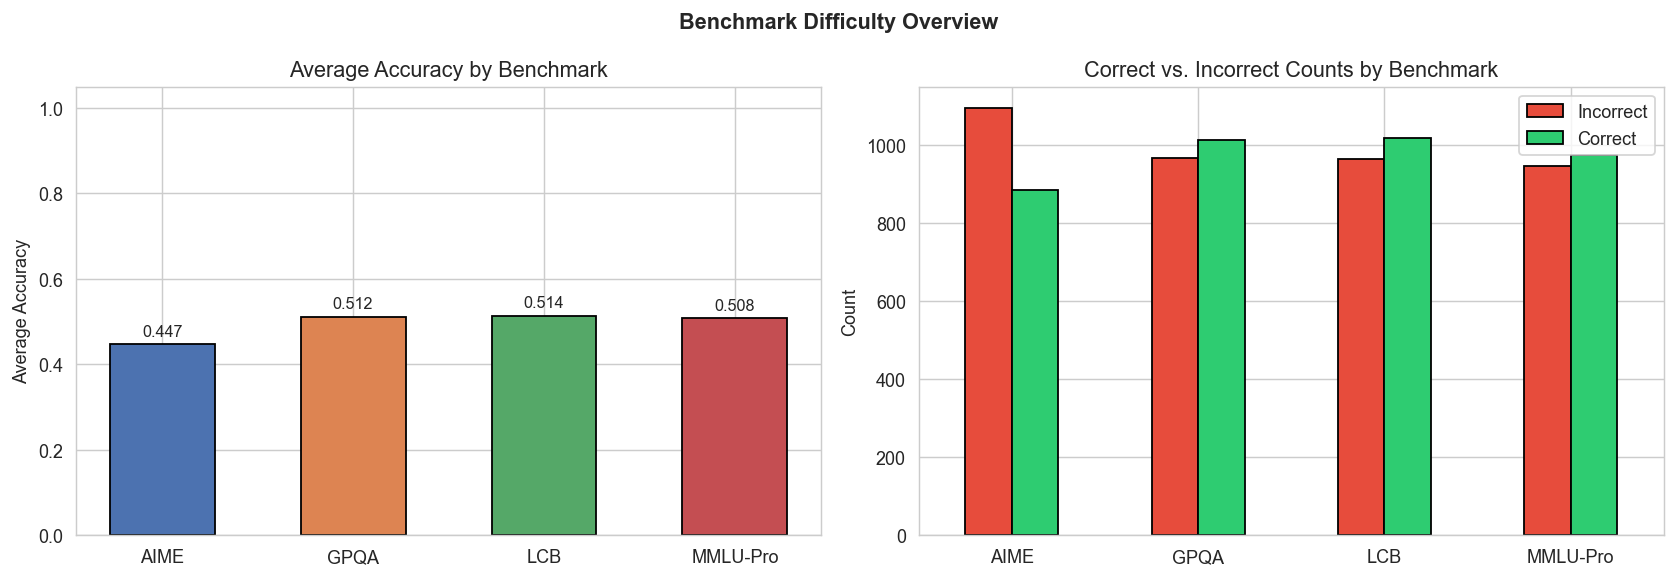

In [ ]:
BENCH_COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
BENCH_ORDER  = ['AIME', 'GPQA', 'LCB', 'MMLU-Pro']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel 1 – average accuracy per benchmark
bench_acc = df.groupby('dataset')['score'].mean().reindex(BENCH_ORDER)
bars = axes[0].bar(BENCH_ORDER, bench_acc, color=BENCH_COLORS, edgecolor='black', width=0.55)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Average Accuracy")
axes[0].set_title("Average Accuracy by Benchmark")
for bar, val in zip(bars, bench_acc):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f"{val:.3f}", ha='center', fontsize=9)

# Panel 2 – correct vs. incorrect counts
bench_counts = df.groupby(['dataset','score']).size().unstack(fill_value=0)
bench_counts.columns = ['Incorrect', 'Correct']
bench_counts.reindex(BENCH_ORDER).plot(kind='bar', ax=axes[1], edgecolor='black',
                                       color=['#e74c3c','#2ecc71'])
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].set_title("Correct vs. Incorrect Counts by Benchmark")
axes[1].set_xticklabels(BENCH_ORDER, rotation=0)
axes[1].legend()

plt.suptitle("Benchmark Difficulty Overview", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_OUT / "01_benchmark_accuracy.png", dpi=150)
plt.show()


From diagram above, there is not really bias of accuracy and benchmark. Which we can use all prompt as resources for optimization

In [5]:
model_stats = (
    df.groupby('model')
      .agg(avg_score=('score','mean'), avg_cost=('cost','mean'),
           n_rows=('prompt_id','count'))
      .reset_index()
      .sort_values('avg_score', ascending=False)
      .reset_index(drop=True)
)
model_stats['tier'] = model_stats['avg_cost'].apply(
    lambda c: 'Free (open-source)' if c == 0 else 'Paid API'
)

print("All 33 models ranked by accuracy:")
print(model_stats[['model','avg_score','avg_cost','tier']].to_string(index=True))


All 33 models ranked by accuracy:
                              model  avg_score  avg_cost                tier
0                             gpt-5   0.887500  0.042548            Paid API
1     qwen3-235b-a22b-thinking-2507   0.845833  0.014699            Paid API
2                  deepseek-r1-0528   0.841667  0.021899            Paid API
3                    gemini-2.5-pro   0.829167  0.108404            Paid API
4                        gpt-5-chat   0.741667  0.004704            Paid API
5                      kimi-k2-0905   0.737500  0.004329            Paid API
6                           glm-4.6   0.737500  0.019497            Paid API
7              qwen3-235b-a22b-2507   0.729167  0.001756            Paid API
8            deepseek-v3.1-terminus   0.705556  0.001615            Paid API
9                  gemini-2.5-flash   0.700000  0.015802            Paid API
10                         Qwen3-8B   0.670833  0.001339            Paid API
11        DeepSeek-R1-0528-Qwen3-8B   0.65

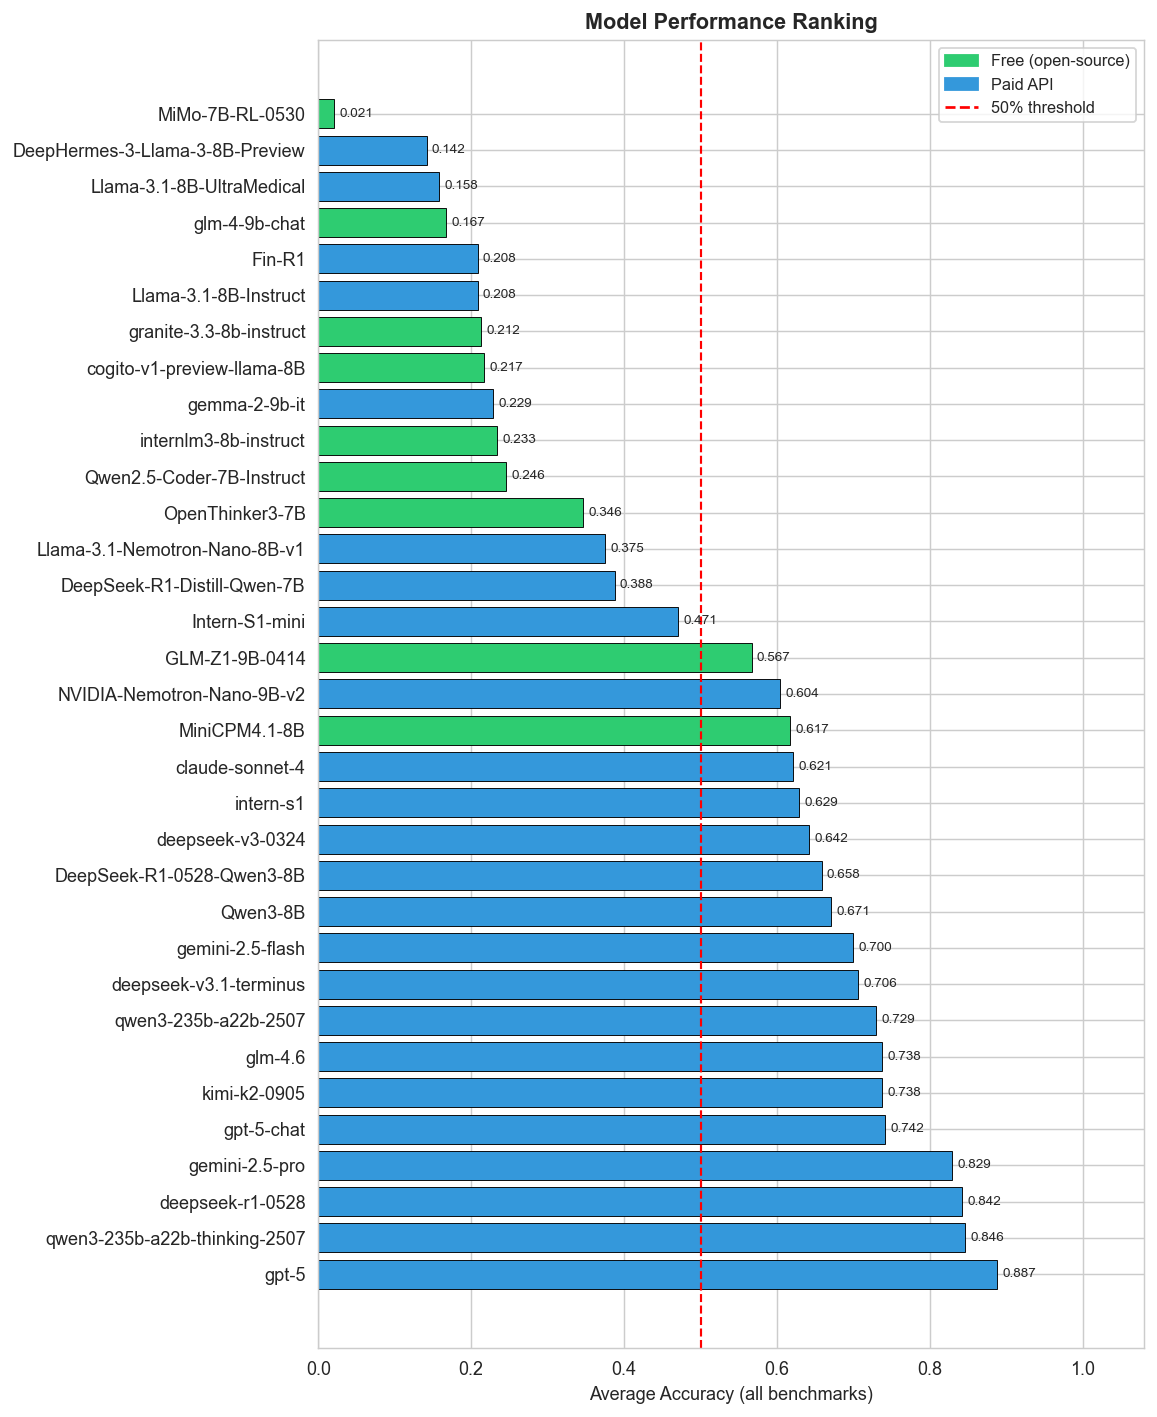

In [6]:
fig, ax = plt.subplots(figsize=(9, 11))

palette = {'Free (open-source)': '#2ecc71', 'Paid API': '#3498db'}
bar_colors = [palette[t] for t in model_stats['tier']]

bars = ax.barh(model_stats['model'], model_stats['avg_score'],
               color=bar_colors, edgecolor='black', linewidth=0.5)
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1.2, label='50% accuracy')
ax.set_xlabel("Average Accuracy (all benchmarks)")
ax.set_title("Model Performance Ranking", fontsize=12, fontweight='bold')
ax.set_xlim(0, 1.08)

for bar, val in zip(bars, model_stats['avg_score']):
    ax.text(val + 0.007, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va='center', fontsize=7.5)

handles = [mpatches.Patch(color='#2ecc71', label='Free (open-source)'),
           mpatches.Patch(color='#3498db', label='Paid API'),
           plt.Line2D([0],[0], color='red', linestyle='--', label='50% threshold')]
ax.legend(handles=handles, fontsize=9)
plt.tight_layout()
plt.savefig(EDA_OUT / "02_model_ranking.png", dpi=150)
plt.show()


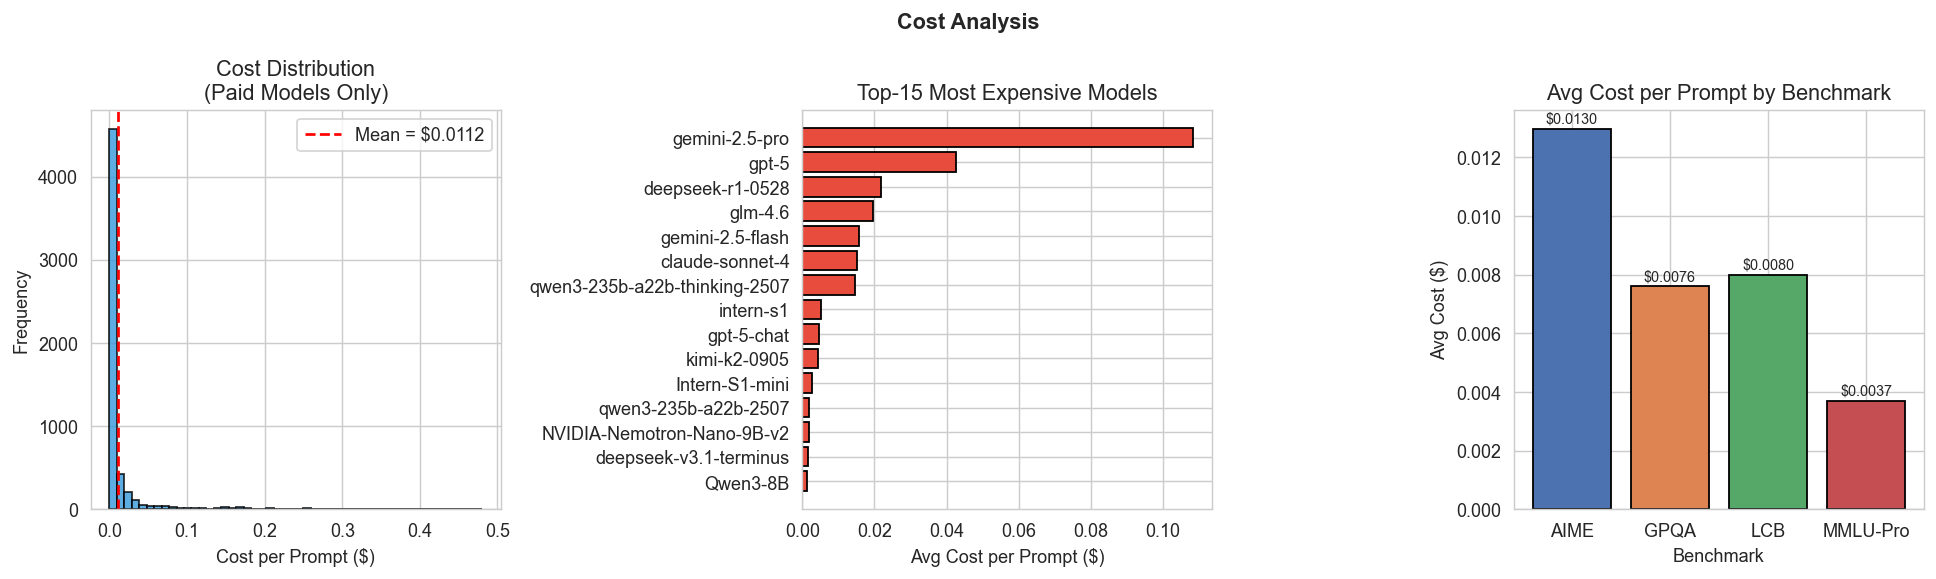

Cost statistics (all prompts):
count    7860.000000
mean        0.008105
std         0.028110
min         0.000000
25%         0.000000
50%         0.000342
75%         0.003582
max         0.480387

% of zero-cost rows: 27.7%


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) histogram of per-prompt costs (paid only)
paid = df[df['cost'] > 0]['cost']
axes[0].hist(paid, bins=50, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].axvline(paid.mean(), color='red', linestyle='--',
                label=f"Mean = ${paid.mean():.4f}")
axes[0].set_xlabel("Cost per Prompt ($)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Cost Distribution\n(Paid Models Only)")
axes[0].legend()

# (b) per-model average cost (top 15 most expensive)
top_cost = (model_stats[model_stats['avg_cost'] > 0]
            .sort_values('avg_cost', ascending=False).head(15))
axes[1].barh(top_cost['model'], top_cost['avg_cost'],
             color='#e74c3c', edgecolor='black')
axes[1].invert_yaxis()
axes[1].set_xlabel("Avg Cost per Prompt ($)")
axes[1].set_title("Top-15 Most Expensive Models")

# (c) average cost per benchmark
bench_cost = df.groupby('dataset')['cost'].mean().reindex(BENCH_ORDER)
axes[2].bar(BENCH_ORDER, bench_cost, color=BENCH_COLORS, edgecolor='black')
axes[2].set_xlabel("Benchmark")
axes[2].set_ylabel("Avg Cost ($)")
axes[2].set_title("Avg Cost per Prompt by Benchmark")
for i,(b,v) in enumerate(bench_cost.items()):
    axes[2].text(i, v + 0.0002, f"${v:.4f}", ha='center', fontsize=8)

plt.suptitle("Cost Analysis", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_OUT / "03_cost_distribution.png", dpi=150)
plt.show()

print("Cost statistics (all prompts):")
print(df['cost'].describe().to_string())
print(f"\n% of zero-cost rows: {(df['cost']==0).mean()*100:.1f}%")


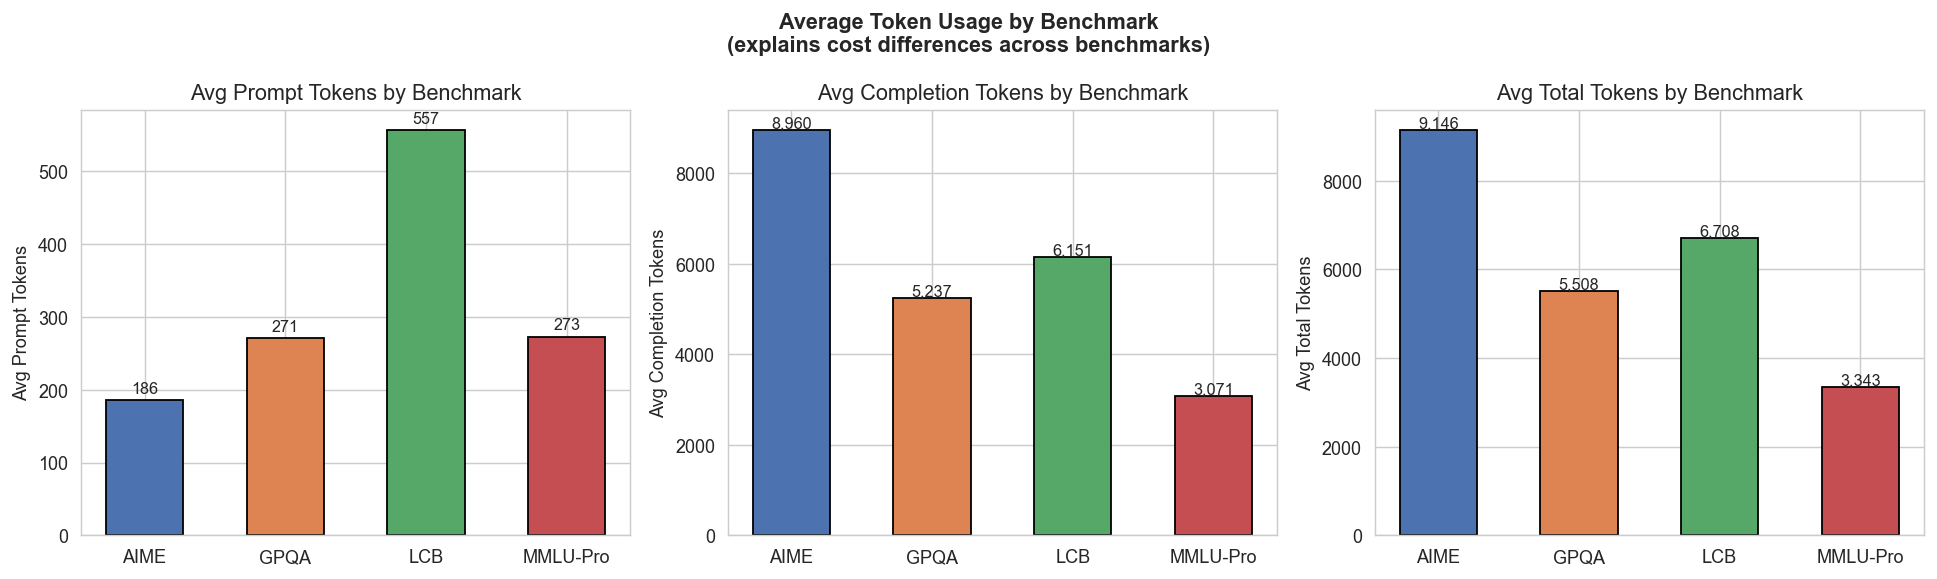

Avg tokens per benchmark:
          Prompt Tokens  Completion Tokens  Total Tokens
dataset                                                 
AIME         185.750000        8960.101010   9145.851010
GPQA         271.106566        5236.787879   5507.894444
LCB          556.780303        6150.813636   6707.593939
MMLU-Pro     272.700000        3070.583854   3343.283854


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

bench_prompt = df.groupby('dataset')['prompt_tokens'].mean().reindex(BENCH_ORDER)
bench_completion = df.groupby('dataset')['completion_tokens'].mean().reindex(BENCH_ORDER)
df['total_tokens'] = df['prompt_tokens'] + df['completion_tokens']
bench_total = df.groupby('dataset')['total_tokens'].mean().reindex(BENCH_ORDER)

# (a) avg prompt tokens per benchmark
bars = axes[0].bar(BENCH_ORDER, bench_prompt, color=BENCH_COLORS, edgecolor='black', width=0.55)
axes[0].set_ylabel("Avg Prompt Tokens")
axes[0].set_title("Avg Prompt Tokens by Benchmark")
for bar, val in zip(bars, bench_prompt):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 10,
                 f"{val:,.0f}", ha='center', fontsize=9)

# (b) avg completion tokens per benchmark
bars = axes[1].bar(BENCH_ORDER, bench_completion, color=BENCH_COLORS, edgecolor='black', width=0.55)
axes[1].set_ylabel("Avg Completion Tokens")
axes[1].set_title("Avg Completion Tokens by Benchmark")
for bar, val in zip(bars, bench_completion):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 50,
                 f"{val:,.0f}", ha='center', fontsize=9)

# (c) avg total tokens per benchmark
bars = axes[2].bar(BENCH_ORDER, bench_total, color=BENCH_COLORS, edgecolor='black', width=0.55)
axes[2].set_ylabel("Avg Total Tokens")
axes[2].set_title("Avg Total Tokens by Benchmark")
for bar, val in zip(bars, bench_total):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 50,
                 f"{val:,.0f}", ha='center', fontsize=9)

plt.suptitle("Average Token Usage by Benchmark\n(explains cost differences across benchmarks)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_OUT / "09_tokens_by_benchmark.png", dpi=150)
plt.show()

print("Avg tokens per benchmark:")
tok_summary = pd.DataFrame({
    'Prompt Tokens': bench_prompt,
    'Completion Tokens': bench_completion,
    'Total Tokens': bench_total,
})
print(tok_summary.to_string())


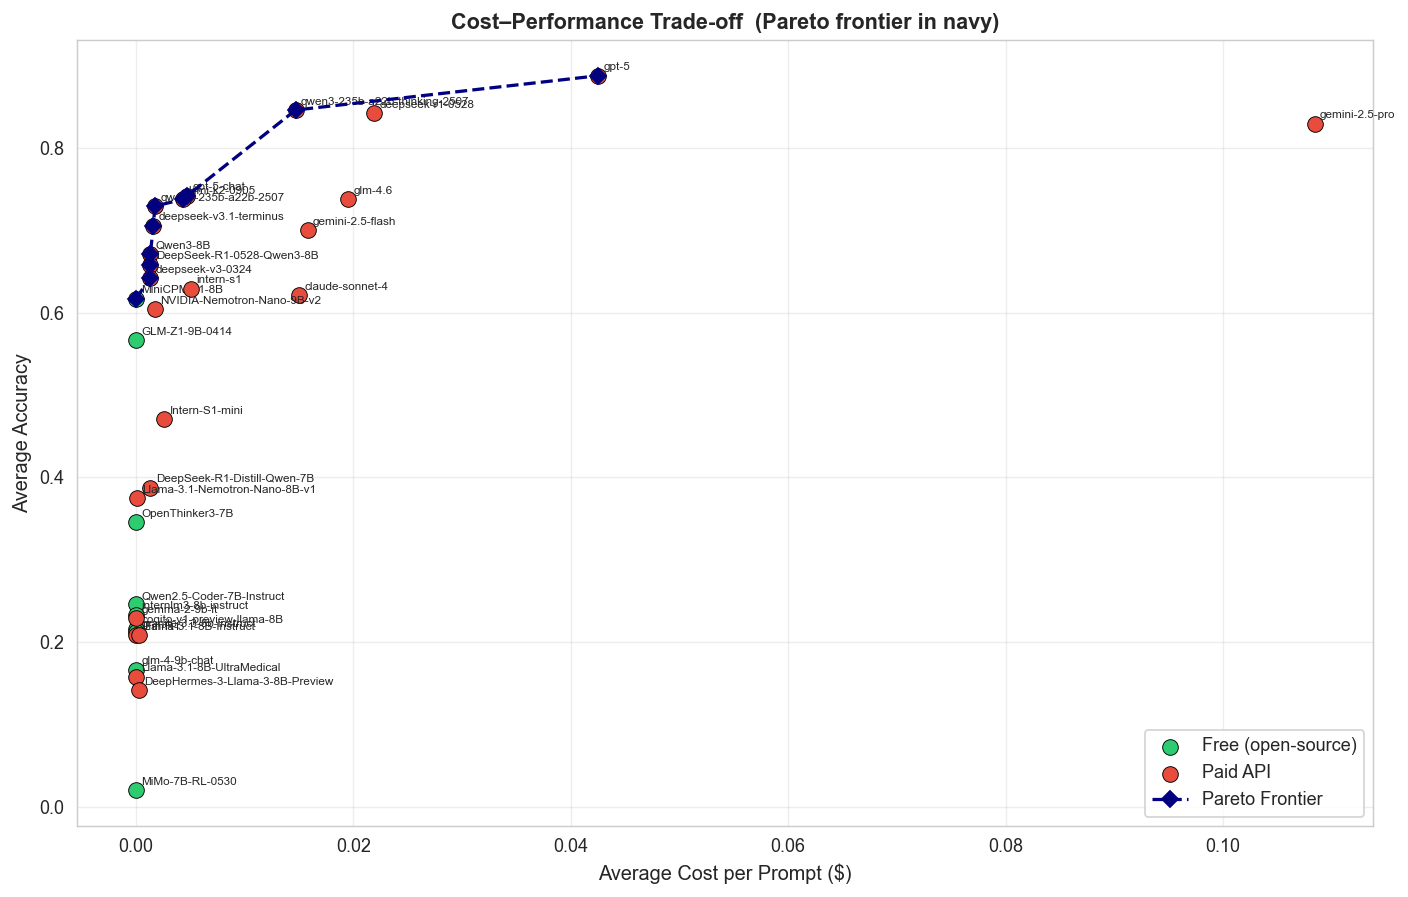

Pareto-optimal models (min cost for given accuracy level):
                        model  avg_score  avg_cost               tier
                MiniCPM4.1-8B   0.616667  0.000000 Free (open-source)
             deepseek-v3-0324   0.641667  0.001311           Paid API
    DeepSeek-R1-0528-Qwen3-8B   0.658333  0.001334           Paid API
                     Qwen3-8B   0.670833  0.001339           Paid API
       deepseek-v3.1-terminus   0.705556  0.001615           Paid API
         qwen3-235b-a22b-2507   0.729167  0.001756           Paid API
                 kimi-k2-0905   0.737500  0.004329           Paid API
                   gpt-5-chat   0.741667  0.004704           Paid API
qwen3-235b-a22b-thinking-2507   0.845833  0.014699           Paid API
                        gpt-5   0.887500  0.042548           Paid API


In [9]:
fig, ax = plt.subplots(figsize=(11, 7))

palette = {'Free (open-source)': '#2ecc71', 'Paid API': '#e74c3c'}
for tier, grp in model_stats.groupby('tier'):
    ax.scatter(grp['avg_cost'], grp['avg_score'],
               c=palette[tier], label=tier,
               s=75, edgecolors='black', linewidths=0.5, zorder=3)
    for _, row in grp.iterrows():
        ax.annotate(row['model'], (row['avg_cost'], row['avg_score']),
                    fontsize=6.5, xytext=(3, 3), textcoords='offset points')

# Pareto frontier (min cost, max score)
pts = model_stats[['avg_cost','avg_score']].values
pareto_mask = [
    not any(
        pts[j,0] <= pts[i,0] and pts[j,1] >= pts[i,1]
        and (pts[j,0] < pts[i,0] or pts[j,1] > pts[i,1])
        for j in range(len(pts)) if j != i
    )
    for i in range(len(pts))
]
pareto_df = model_stats[pareto_mask].sort_values('avg_cost')
ax.plot(pareto_df['avg_cost'], pareto_df['avg_score'],
        color='navy', linewidth=1.8, linestyle='--',
        marker='D', markersize=6, zorder=4, label='Pareto Frontier')

ax.set_xlabel("Average Cost per Prompt ($)", fontsize=11)
ax.set_ylabel("Average Accuracy", fontsize=11)
ax.set_title("Cost–Performance Trade-off  (Pareto frontier in navy)",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(EDA_OUT / "04_cost_performance.png", dpi=150)
plt.show()

print("Pareto-optimal models (min cost for given accuracy level):")
print(pareto_df[['model','avg_score','avg_cost','tier']].to_string(index=False))


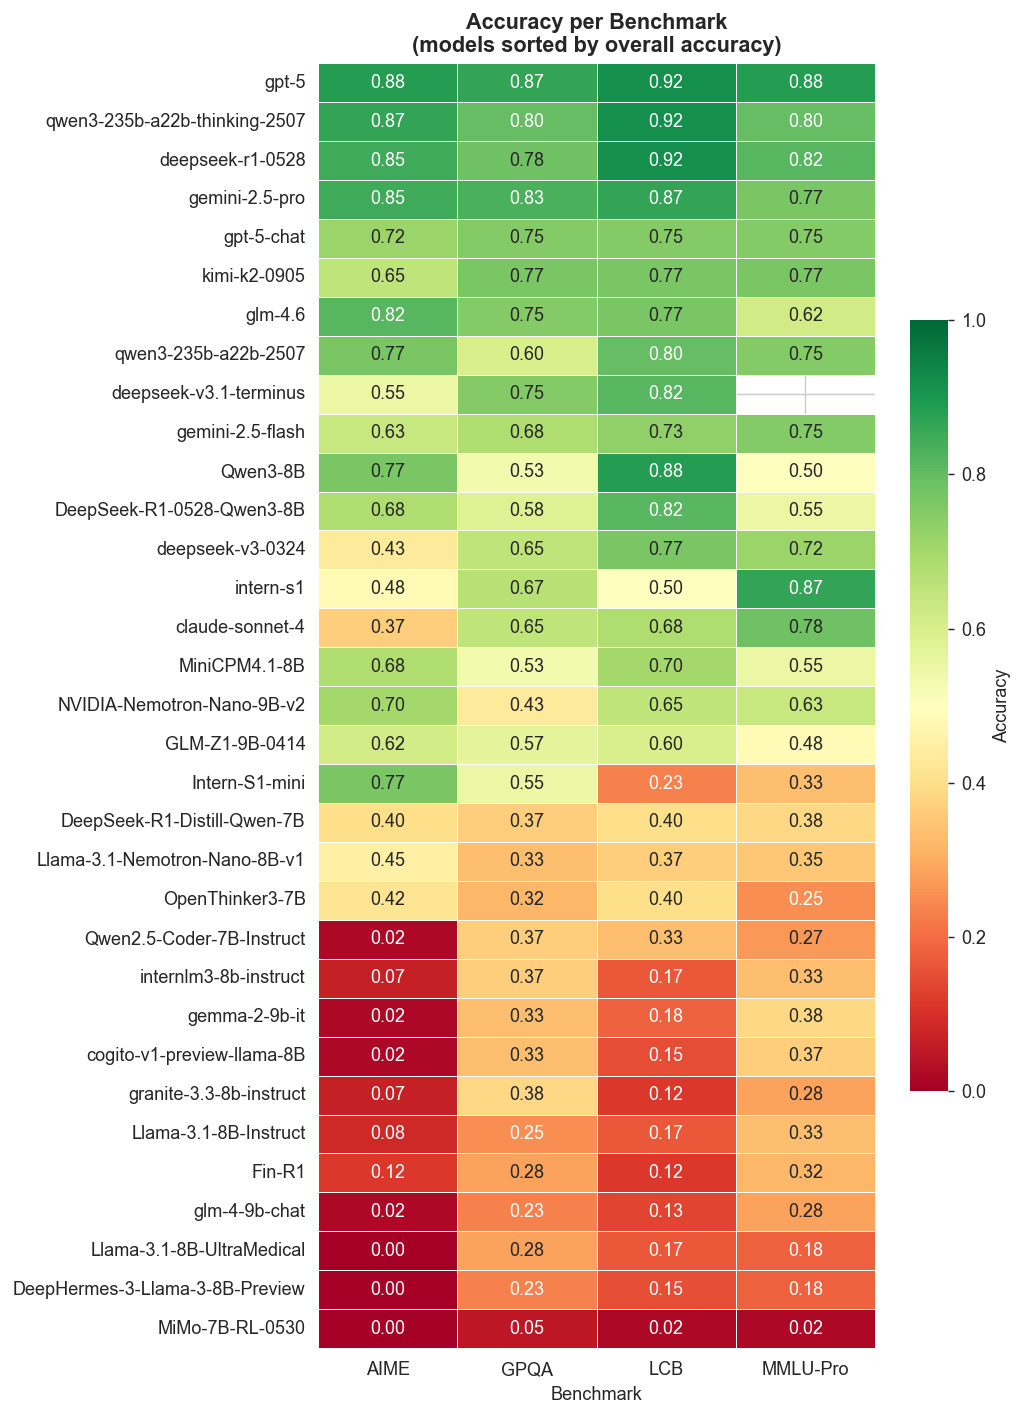

In [10]:
pivot = (df.groupby(['model','dataset'])['score']
           .mean()
           .unstack()
           .reindex(columns=BENCH_ORDER)
           .reindex(model_stats['model'].values))  # sorted by overall accuracy

fig, ax = plt.subplots(figsize=(8, 11))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.3, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Accuracy', 'shrink': 0.6})
ax.set_title("Accuracy per Benchmark\n(models sorted by overall accuracy)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Benchmark")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(EDA_OUT / "05_accuracy_heatmap.png", dpi=150)
plt.show()


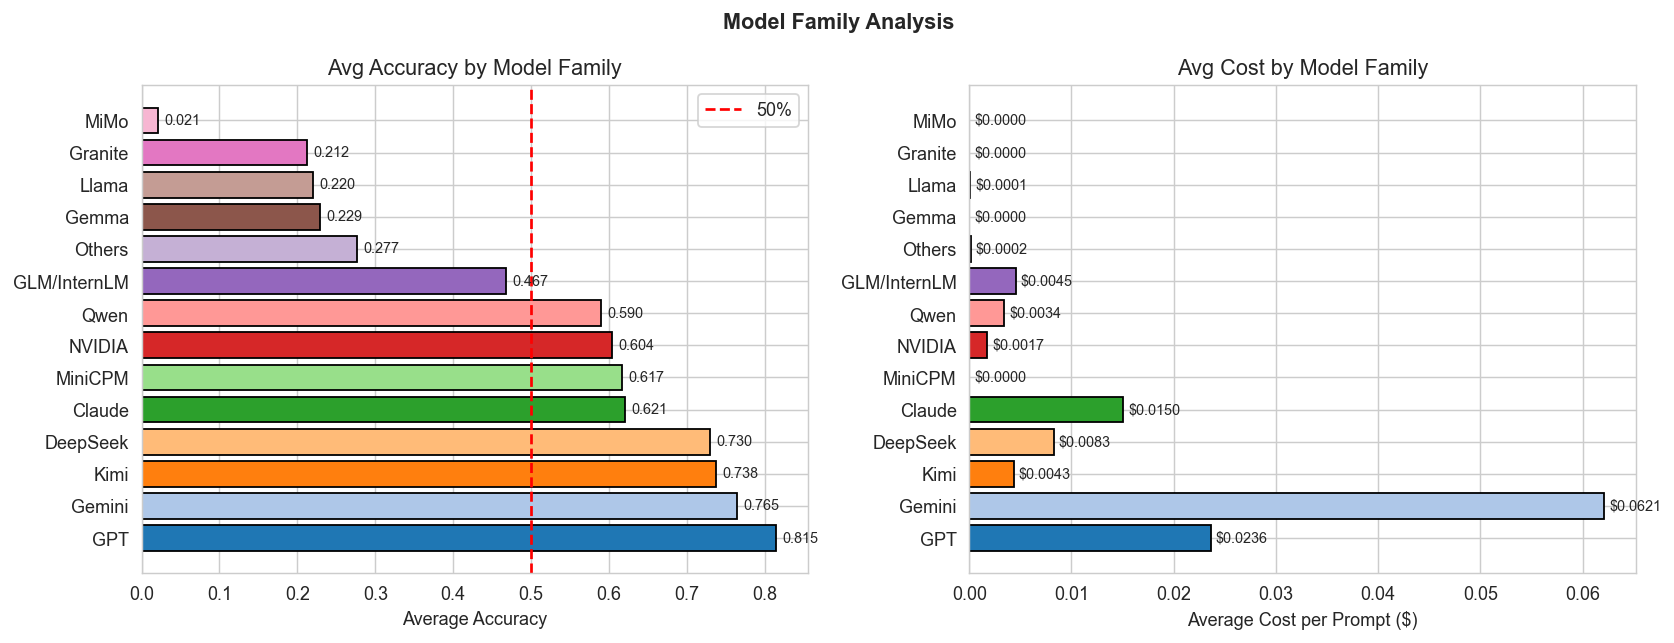

      family  avg_score  avg_cost  n_models
         GPT   0.814583  0.023626         2
      Gemini   0.764583  0.062103         2
        Kimi   0.737500  0.004329         1
    DeepSeek   0.729630  0.008275         3
      Claude   0.620833  0.015043         1
     MiniCPM   0.616667  0.000000         1
      NVIDIA   0.604167  0.001746         1
        Qwen   0.589583  0.003410         6
GLM/InternLM   0.467361  0.004536         6
      Others   0.277083  0.000152         2
       Gemma   0.229167  0.000019         1
       Llama   0.220000  0.000087         5
     Granite   0.212500  0.000000         1
        MiMo   0.020833  0.000000         1


In [11]:
def get_family(name):
    n = name.lower()
    if 'gpt' in n:                            return 'GPT'
    if 'gemini' in n:                         return 'Gemini'
    if 'claude' in n:                         return 'Claude'
    if 'qwen' in n:                           return 'Qwen'
    if 'deepseek' in n:                       return 'DeepSeek'
    if 'llama' in n:                          return 'Llama'
    if 'glm' in n or 'internlm' in n:         return 'GLM/InternLM'
    if 'intern' in n:                         return 'GLM/InternLM'
    if 'kimi' in n:                           return 'Kimi'
    if 'gemma' in n:                          return 'Gemma'
    if 'granite' in n:                        return 'Granite'
    if 'mimo' in n:                           return 'MiMo'
    if 'minicpm' in n:                        return 'MiniCPM'
    if 'nvidia' in n or 'nemotron' in n:      return 'NVIDIA'
    return 'Others'

model_stats['family'] = model_stats['model'].apply(get_family)

family_stats = (
    model_stats.groupby('family')
               .agg(avg_score=('avg_score','mean'),
                    avg_cost=('avg_cost','mean'),
                    n_models=('model','count'))
               .reset_index()
               .sort_values('avg_score', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fam_colors = plt.cm.tab20.colors[:len(family_stats)]

axes[0].barh(family_stats['family'], family_stats['avg_score'],
             color=fam_colors, edgecolor='black')
axes[0].axvline(0.5, color='red', linestyle='--', label='50%')
axes[0].set_xlabel("Average Accuracy")
axes[0].set_title("Avg Accuracy by Model Family")
axes[0].legend()
for bar, val in zip(axes[0].patches, family_stats['avg_score']):
    axes[0].text(val+0.008, bar.get_y()+bar.get_height()/2,
                 f"{val:.3f}", va='center', fontsize=8)

axes[1].barh(family_stats['family'], family_stats['avg_cost'],
             color=fam_colors, edgecolor='black')
axes[1].set_xlabel("Average Cost per Prompt ($)")
axes[1].set_title("Avg Cost by Model Family")
for bar, val in zip(axes[1].patches, family_stats['avg_cost']):
    axes[1].text(val+0.0005, bar.get_y()+bar.get_height()/2,
                 f"${val:.4f}", va='center', fontsize=8)

plt.suptitle("Model Family Analysis", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_OUT / "06_family_analysis.png", dpi=150)
plt.show()

print(family_stats.to_string(index=False))


/var/folders/j6/swly69kd7tv2w41k73stjz7c0000gn/T/ipykernel_76718/3346074029.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_bench, patch_artist=True, labels=BENCH_ORDER)
/var/folders/j6/swly69kd7tv2w41k73stjz7c0000gn/T/ipykernel_76718/3346074029.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[2].boxplot(data_var, patch_artist=True, labels=BENCH_ORDER)


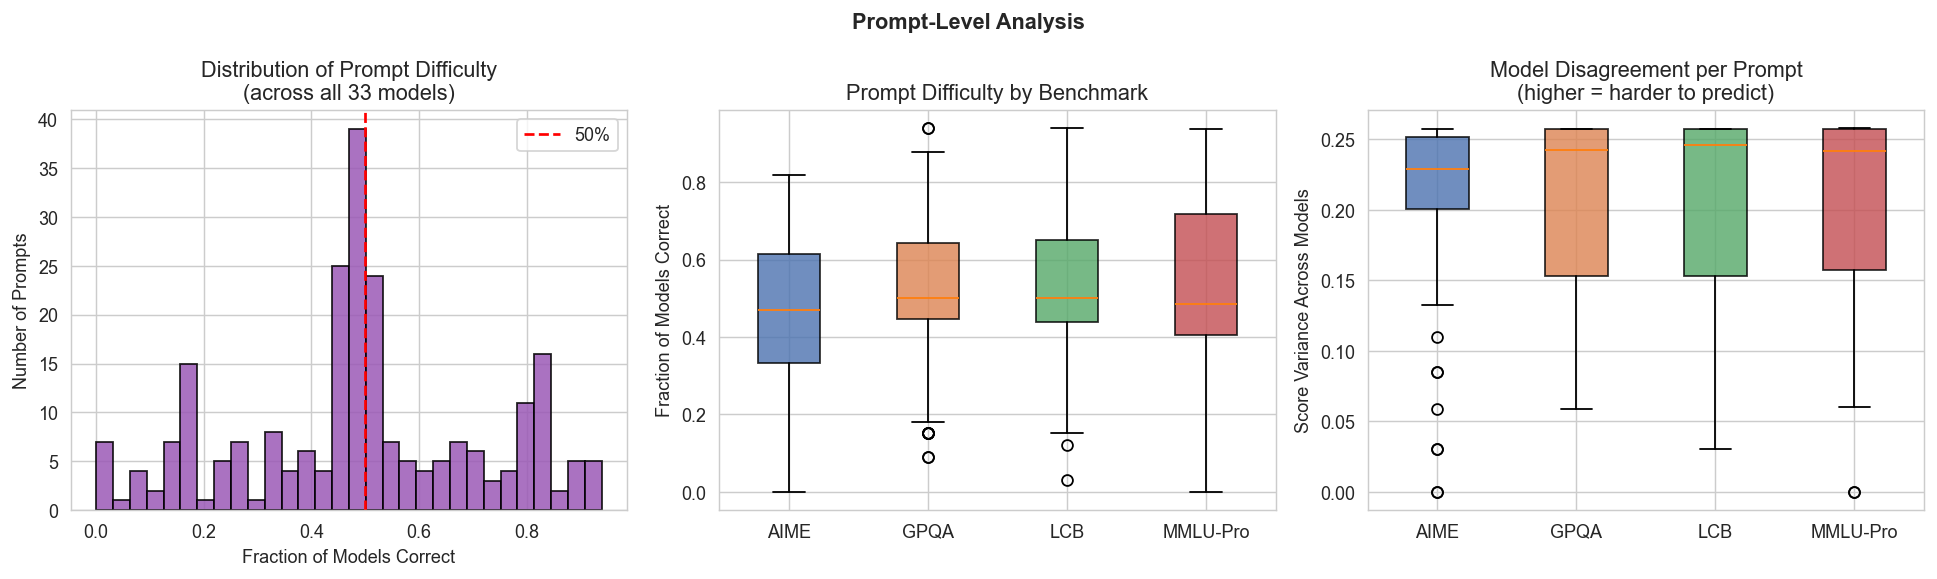

Average difficulty per benchmark (lower = harder):
dataset
AIME        0.446970
GPQA        0.511616
LCB         0.513636
MMLU-Pro    0.507812

Prompts solvable by NO model  : 4
Prompts solved by ALL models  : 0


In [12]:
prompt_stats = (
    df.groupby(['prompt_id','dataset'])['score']
      .agg(avg_score='mean', variance='var', n_models='count')
      .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) histogram of per-prompt difficulty
axes[0].hist(prompt_stats['avg_score'], bins=30,
             color='#9b59b6', edgecolor='black', alpha=0.85)
axes[0].axvline(0.5, color='red', linestyle='--', label='50%')
axes[0].set_xlabel("Fraction of Models Correct")
axes[0].set_ylabel("Number of Prompts")
axes[0].set_title("Distribution of Prompt Difficulty\n(across all 33 models)")
axes[0].legend()

# (b) box plot of difficulty per benchmark
data_by_bench = [prompt_stats[prompt_stats['dataset']==b]['avg_score'].values
                 for b in BENCH_ORDER]
bp = axes[1].boxplot(data_by_bench, patch_artist=True, labels=BENCH_ORDER)
for patch, c in zip(bp['boxes'], BENCH_COLORS):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)
axes[1].set_ylabel("Fraction of Models Correct")
axes[1].set_title("Prompt Difficulty by Benchmark")

# (c) model disagreement (variance) per benchmark
data_var = [prompt_stats[prompt_stats['dataset']==b]['variance'].values
            for b in BENCH_ORDER]
bp2 = axes[2].boxplot(data_var, patch_artist=True, labels=BENCH_ORDER)
for patch, c in zip(bp2['boxes'], BENCH_COLORS):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)
axes[2].set_ylabel("Score Variance Across Models")
axes[2].set_title("Model Disagreement per Prompt\n(higher = harder to predict)")

plt.suptitle("Prompt-Level Analysis", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_OUT / "07_prompt_difficulty.png", dpi=150)
plt.show()

print("Average difficulty per benchmark (lower = harder):")
print(prompt_stats.groupby('dataset')['avg_score'].mean().reindex(BENCH_ORDER).to_string())
print(f"\nPrompts solvable by NO model  : {(prompt_stats['avg_score']==0).sum()}")
print(f"Prompts solved by ALL models  : {(prompt_stats['avg_score']==1).sum()}")


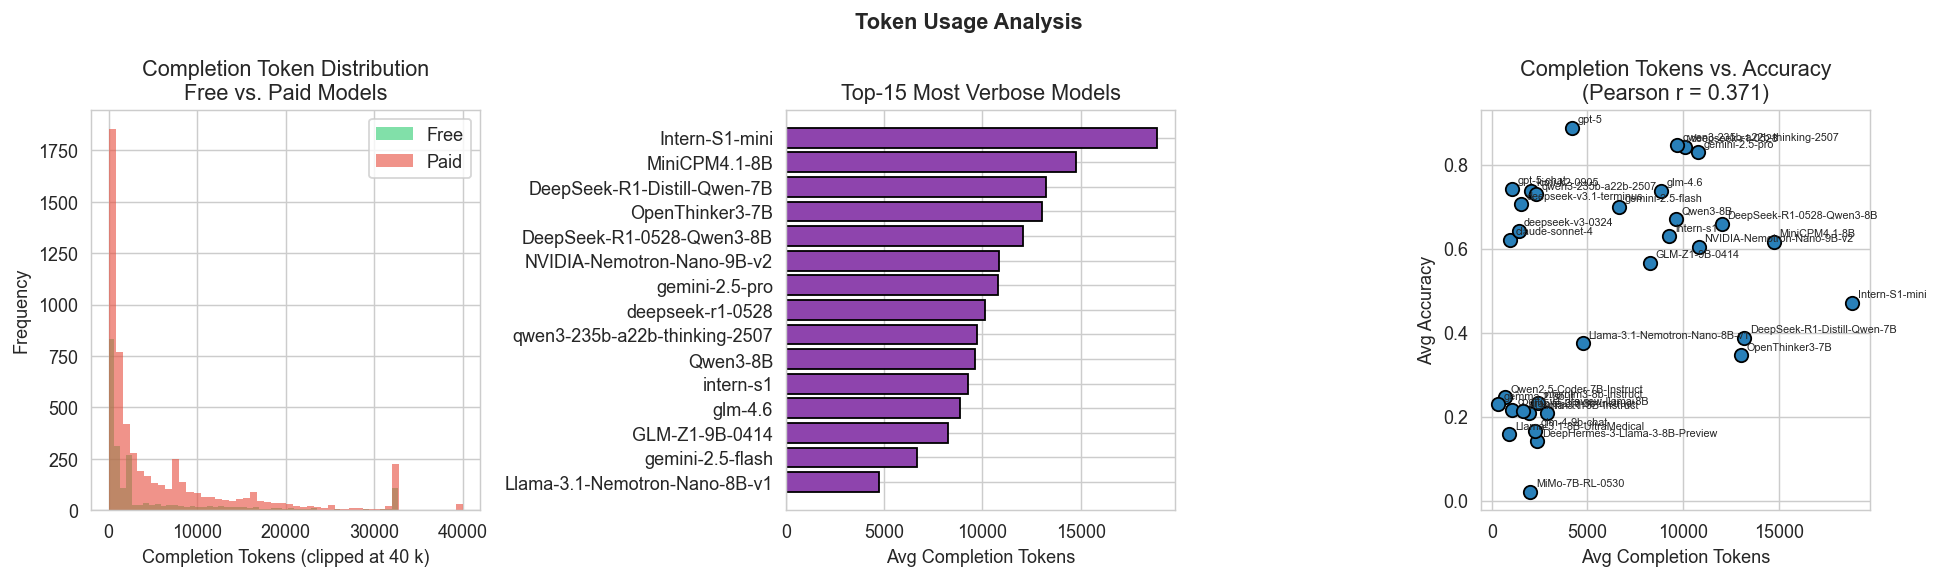

Mean completion tokens (free models) : 5,083
Mean completion tokens (paid models) : 6,066
Tokens–accuracy correlation          : 0.371


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) completion tokens: free vs. paid
free_tok = df[df['cost']==0]['completion_tokens'].clip(upper=40_000)
paid_tok = df[df['cost']>0 ]['completion_tokens'].clip(upper=40_000)
axes[0].hist(free_tok, bins=50, alpha=0.6, color='#2ecc71',
             label='Free', edgecolor='none')
axes[0].hist(paid_tok, bins=50, alpha=0.6, color='#e74c3c',
             label='Paid', edgecolor='none')
axes[0].set_xlabel("Completion Tokens (clipped at 40 k)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Completion Token Distribution\nFree vs. Paid Models")
axes[0].legend()

# (b) top-15 most verbose models
tok_per_model = (df.groupby('model')['completion_tokens']
                   .mean()
                   .sort_values(ascending=False)
                   .head(15))
axes[1].barh(tok_per_model.index, tok_per_model.values,
             color='#8e44ad', edgecolor='black')
axes[1].invert_yaxis()
axes[1].set_xlabel("Avg Completion Tokens")
axes[1].set_title("Top-15 Most Verbose Models")

# (c) avg completion tokens vs. accuracy per model
model_tok = (df.groupby('model')
               .agg(avg_score=('score','mean'),
                    avg_tokens=('completion_tokens','mean'))
               .reset_index())
axes[2].scatter(model_tok['avg_tokens'], model_tok['avg_score'],
                color='#2980b9', edgecolors='black', s=55)
for _, row in model_tok.iterrows():
    axes[2].annotate(row['model'], (row['avg_tokens'], row['avg_score']),
                     fontsize=6, xytext=(3,3), textcoords='offset points')
r = model_tok[['avg_tokens','avg_score']].corr().iloc[0,1]
axes[2].set_xlabel("Avg Completion Tokens")
axes[2].set_ylabel("Avg Accuracy")
axes[2].set_title(f"Completion Tokens vs. Accuracy\n(Pearson r = {r:.3f})")

plt.suptitle("Token Usage Analysis", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_OUT / "08_token_analysis.png", dpi=150)
plt.show()

print(f"Mean completion tokens (free models) : {free_tok.mean():,.0f}")
print(f"Mean completion tokens (paid models) : {paid_tok.mean():,.0f}")
print(f"Tokens–accuracy correlation          : {r:.3f}")


In [14]:
best_free = model_stats[model_stats['avg_cost']==0].iloc[0]
most_exp  = model_stats.sort_values('avg_cost', ascending=False).iloc[0]
hardest   = prompt_stats.groupby('dataset')['avg_score'].mean().idxmin()
easiest   = prompt_stats.groupby('dataset')['avg_score'].mean().idxmax()

print("=" * 65)
print("EDA SUMMARY")
print("=" * 65)
print(f"  Dataset         : RouterBench (Li et al. 2026)")
print(f"  Size            : 33 models × 240 prompts = 7,860 rows")
print(f"  Benchmarks      : AIME (Math), GPQA (Science),")
print(f"                    LCB (Code), MMLU-Pro (Knowledge)")
print()
print(f"  Best model      : {model_stats.iloc[0]['model']}")
print(f"                    acc={model_stats.iloc[0]['avg_score']:.3f}, "
      f"cost=${model_stats.iloc[0]['avg_cost']:.4f}")
print(f"  Best free model : {best_free['model']}  "
      f"acc={best_free['avg_score']:.3f}")
print(f"  Most expensive  : {most_exp['model']}  "
      f"cost=${most_exp['avg_cost']:.4f}")
print()
print(f"  Hardest bench   : {hardest}  "
      f"(acc={prompt_stats.groupby('dataset')['avg_score'].mean()[hardest]:.3f})")
print(f"  Easiest bench   : {easiest}  "
      f"(acc={prompt_stats.groupby('dataset')['avg_score'].mean()[easiest]:.3f})")
print()
print(f"  Prompts with 0 models correct  : {(prompt_stats['avg_score']==0).sum()}")
print(f"  Prompts with all models correct: {(prompt_stats['avg_score']==1).sum()}")
print()
print("  Key insights:")
print("  • Huge cost gap (100×) between frontier and open-source models")
print("  • Several free models exceed 60% accuracy — good routing anchors")
print("  • AIME is hardest; MMLU-Pro is most approachable")
print("  • No single model dominates on both cost AND quality")
print("  • Pareto frontier justifies multi-model routing over single-model use")


EDA SUMMARY
  Dataset         : RouterBench (Li et al. 2026)
  Size            : 33 models × 240 prompts = 7,860 rows
  Benchmarks      : AIME (Math), GPQA (Science),
                    LCB (Code), MMLU-Pro (Knowledge)

  Best model      : gpt-5
                    acc=0.887, cost=$0.0425
  Best free model : MiniCPM4.1-8B  acc=0.617
  Most expensive  : gemini-2.5-pro  cost=$0.1084

  Hardest bench   : AIME  (acc=0.447)
  Easiest bench   : LCB  (acc=0.514)

  Prompts with 0 models correct  : 4
  Prompts with all models correct: 0

  Key insights:
  • Huge cost gap (100×) between frontier and open-source models
  • Several free models exceed 60% accuracy — good routing anchors
  • AIME is hardest; MMLU-Pro is most approachable
  • No single model dominates on both cost AND quality
  • Pareto frontier justifies multi-model routing over single-model use


## Data Structure

- `prompt_id`: The unique id for each prompt. There are **240** unique values
- `dataset`: The dataset of the peompt comes from. There are **4** unique dataset
    - (Math) AIME
    - (Code) LCB
    - (Knowledge) GPQA, MMLU-Pro
- `model`: AI model that we can choose into our pool from. There are **33** unique models
- `score`: Binary, 1 indicate as correct and 0 indicate as incoeect
- `cost`: The cost of the promt using the model
- `prompt_token`: The token that input from the prompt
- `completion_token`: The token to generate the answer of the prompt

There are 16 models that are open resources, which the cost is 0